In [68]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [69]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start=start, end=end)

C:\Users\Manasa\AppData\Local\Temp\ipykernel_28088\2797349564.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [70]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [71]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-10-18,107198.265625,107490.984375,106387.453125,106483.734375,37779905278
2025-10-19,108666.710938,109488.992188,106157.789062,107204.312500,47657008953
2025-10-20,110588.929688,111711.031250,107485.015625,108667.445312,63507793085
2025-10-21,108476.890625,113996.343750,107534.750000,110587.632812,101194375480
2025-10-22,107909.062500,108705.507812,107701.414062,108380.007812,101551628288


In [72]:
stock_data.describe().T  # You can add the .T to transpose the table for better readability

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,BTC-USD,4054.0,2.567234e+04,3.059741e+04,1.781030e+02,2.549330e+03,1.038612e+04,4.019565e+04,1.247525e+05
High,BTC-USD,4054.0,2.616912e+04,3.110250e+04,2.117310e+02,2.618202e+03,1.065790e+04,4.142759e+04,1.261981e+05
Low,BTC-USD,4054.0,2.509834e+04,3.001635e+04,1.715100e+02,2.481825e+03,1.015216e+04,3.931110e+04,1.231960e+05
Open,BTC-USD,4054.0,2.564690e+04,3.057351e+04,1.768970e+02,2.548100e+03,1.037891e+04,4.012220e+04,1.247521e+05
Volume,BTC-USD,4054.0,2.099871e+10,2.234732e+10,5.914570e+06,1.158242e+09,1.671679e+10,3.248872e+10,3.509679e+11


In [73]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4054 entries, 2014-09-17 to 2025-10-22
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4054 non-null   float64
 1   (High, BTC-USD)    4054 non-null   float64
 2   (Low, BTC-USD)     4054 non-null   float64
 3   (Open, BTC-USD)    4054 non-null   float64
 4   (Volume, BTC-USD)  4054 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 190.0 KB


In [74]:
stock_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [75]:
# CLOSE price data (is very important for prediction of stock prices or cryptocurrency)
closing_price = stock_data[['Close']]

In [76]:
closing_price

Price,Close
Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2025-10-18,107198.265625
2025-10-19,108666.710938


In [77]:
closing_price['Close']

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2025-10-18,107198.265625
2025-10-19,108666.710938
2025-10-20,110588.929688


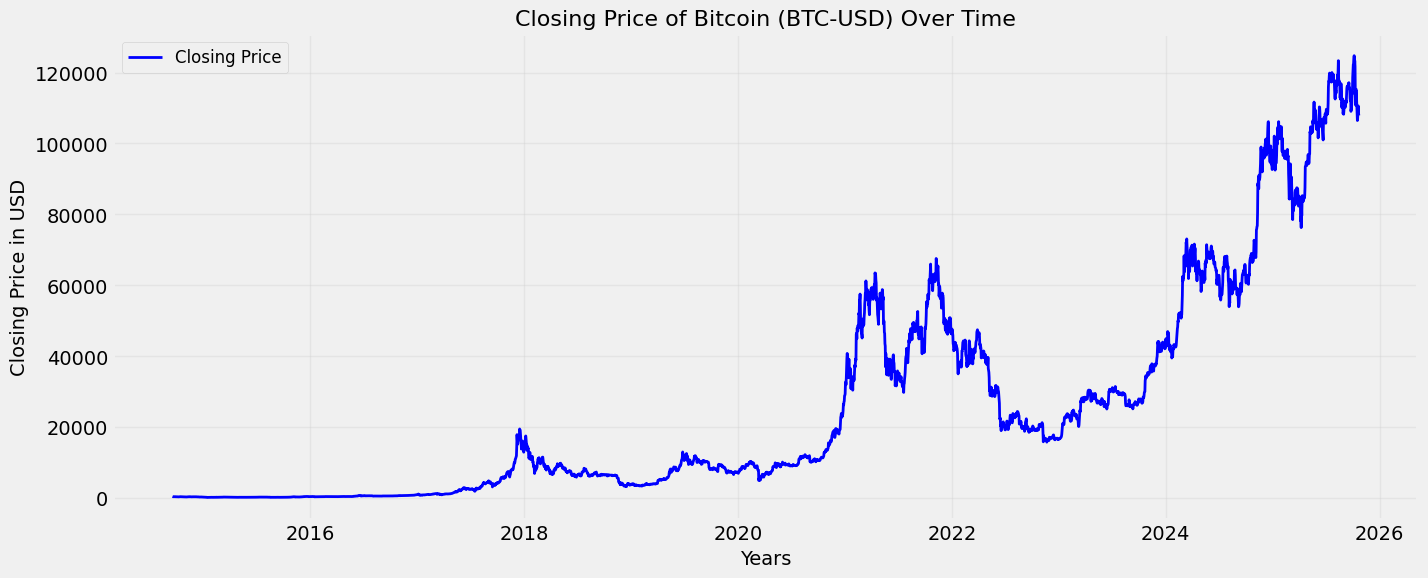

In [78]:
# Plotting the closing price with enhancement
plt.figure(figsize=(15,6))
plt.plot(closing_price.index, closing_price['Close'], label='Closing Price', color='blue', linewidth=2)
plt.title('Closing Price of Bitcoin (BTC-USD) Over Time', fontsize=16)
plt.xlabel('Years', fontsize=14)
plt.ylabel('Closing Price in USD', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [79]:
# Moving Average
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# Moving average for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[0:5])/5)  # 30.0
print(sum(temp_data[1:6])/5)  # 40.0

30.0
40.0


In [80]:
df1 = pd.DataFrame(temp_data)

In [81]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [82]:
for i in range(2014, 2025):
    print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366


In [83]:
closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()  # 365 days moving average
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()  # 100 days moving average

C:\Users\Manasa\AppData\Local\Temp\ipykernel_28088\607612210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()  # 365 days moving average
C:\Users\Manasa\AppData\Local\Temp\ipykernel_28088\607612210.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()  # 100 days moving average


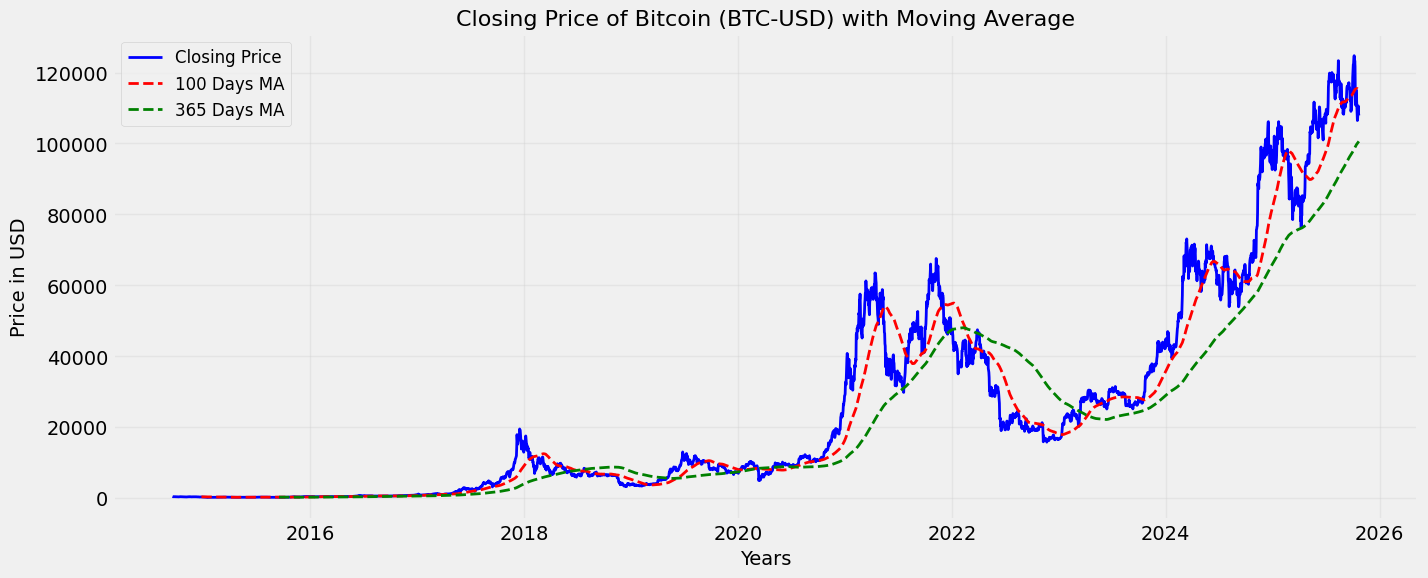

In [84]:
plt.figure(figsize=(15,6))
plt.plot(closing_price.index, closing_price['Close'], label='Closing Price', color='blue', linewidth=2)
plt.plot(closing_price.index, closing_price['MA_100'], label='100 Days MA', color='red', linestyle='--', linewidth=2)
plt.plot(closing_price.index, closing_price['MA_365'], label='365 Days MA', color='green', linestyle='--', linewidth=2)
plt.title('Closing Price of Bitcoin (BTC-USD) with Moving Average', fontsize=16)
plt.xlabel('Years', fontsize=14)
plt.ylabel('Price in USD', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [85]:
# Use the LSTM model for prediction -> Long Short Term Memory
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [86]:
scaled_data

array([[0.00224148],
       [0.00197743],
       [0.00173947],
       ...,
       [0.8863041 ],
       [0.86935007],
       [0.86479192]], shape=(4054, 1))

In [87]:
import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [88]:
# Prepare data for LSTM model
x_data = []
y_data = []
base_days=100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])
x_data, y_data = np.array(x_data), np.array(y_data)

In [89]:
# Split the data into training and testing sets
train_size = int(len(x_data)*0.9)
x_train, y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [90]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
]) 
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\Manasa\OneDrive\Desktop\Stock Analysis Studying\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model.fit(x_train, y_train, batch_size=5, epochs=30)

Epoch 1/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 4.6684e-04
Epoch 2/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 2.1558e-04
Epoch 3/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 1.3844e-04
Epoch 4/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.2040e-04
Epoch 5/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.2239e-04
Epoch 6/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.0041e-04
Epoch 7/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.0273e-04
Epoch 8/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 9.0577e-05
Epoch 9/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.0421e-04
Epoch 10/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 9.9459e-05
Epoch 11/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 1.0834e-04
Epoch 12/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 8.0107e-05
Epoch 13/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.0005e-04
Epoch 14/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22

In [92]:
predictions = model.predict(x_test)
inverse_predictions = scaler.inverse_transform(predictions)
inverse_y_test = scaler.inverse_transform(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [93]:
predictions

array([[0.50553954],
       [0.50707304],
       [0.504627  ],
       [0.5113435 ],
       [0.50373346],
       [0.51763713],
       [0.5241413 ],
       [0.52524424],
       [0.52315605],
       [0.5057305 ],
       [0.48518044],
       [0.48179993],
       [0.48351693],
       [0.49421692],
       [0.49611616],
       [0.5015013 ],
       [0.49758506],
       [0.49586728],
       [0.4840715 ],
       [0.48030326],
       [0.49635717],
       [0.5042167 ],
       [0.50224745],
       [0.52507126],
       [0.5348985 ],
       [0.53916955],
       [0.5372453 ],
       [0.54377556],
       [0.5439609 ],
       [0.5483053 ],
       [0.53691745],
       [0.5352658 ],
       [0.52877843],
       [0.54087865],
       [0.5318776 ],
       [0.5332242 ],
       [0.54040694],
       [0.5557405 ],
       [0.57779324],
       [0.57702994],
       [0.5602561 ],
       [0.5521612 ],
       [0.5500628 ],
       [0.54635537],
       [0.53962004],
       [0.5504931 ],
       [0.5978131 ],
       [0.605

In [94]:
inverse_predictions

array([[ 63155.4  ],
       [ 63346.438],
       [ 63041.72 ],
       [ 63878.42 ],
       [ 62930.41 ],
       [ 64662.45 ],
       [ 65472.707],
       [ 65610.1  ],
       [ 65349.965],
       [ 63179.19 ],
       [ 60619.176],
       [ 60198.05 ],
       [ 60411.945],
       [ 61744.89 ],
       [ 61981.49 ],
       [ 62652.34 ],
       [ 62164.477],
       [ 61950.484],
       [ 60481.03 ],
       [ 60011.605],
       [ 62011.51 ],
       [ 62990.605],
       [ 62745.29 ],
       [ 65588.555],
       [ 66812.78 ],
       [ 67344.836],
       [ 67105.125],
       [ 67918.63 ],
       [ 67941.73 ],
       [ 68482.914],
       [ 67064.29 ],
       [ 66858.53 ],
       [ 66050.375],
       [ 67557.75 ],
       [ 66436.445],
       [ 66604.2  ],
       [ 67498.984],
       [ 69409.16 ],
       [ 72156.37 ],
       [ 72061.27 ],
       [ 69971.69 ],
       [ 68963.266],
       [ 68701.86 ],
       [ 68240.01 ],
       [ 67400.96 ],
       [ 68755.47 ],
       [ 74650.33 ],
       [ 7560

In [95]:
inverse_y_test

array([[ 63648.7109375 ],
       [ 63329.80078125],
       [ 64301.96875   ],
       [ 63143.14453125],
       [ 65181.01953125],
       [ 65790.6640625 ],
       [ 65887.6484375 ],
       [ 65635.3046875 ],
       [ 63329.5       ],
       [ 60837.0078125 ],
       [ 60632.78515625],
       [ 60759.40234375],
       [ 62067.4765625 ],
       [ 62089.94921875],
       [ 62818.953125  ],
       [ 62236.66015625],
       [ 62131.96875   ],
       [ 60582.1015625 ],
       [ 60274.5       ],
       [ 62445.08984375],
       [ 63193.0234375 ],
       [ 62851.375     ],
       [ 66046.125     ],
       [ 67041.109375  ],
       [ 67612.71875   ],
       [ 67399.8359375 ],
       [ 68418.7890625 ],
       [ 68362.734375  ],
       [ 69001.703125  ],
       [ 67367.8515625 ],
       [ 67361.40625   ],
       [ 66432.1953125 ],
       [ 68161.0546875 ],
       [ 66642.4140625 ],
       [ 67014.6953125 ],
       [ 67929.296875  ],
       [ 69907.7578125 ],
       [ 72720.4921875 ],
       [ 723

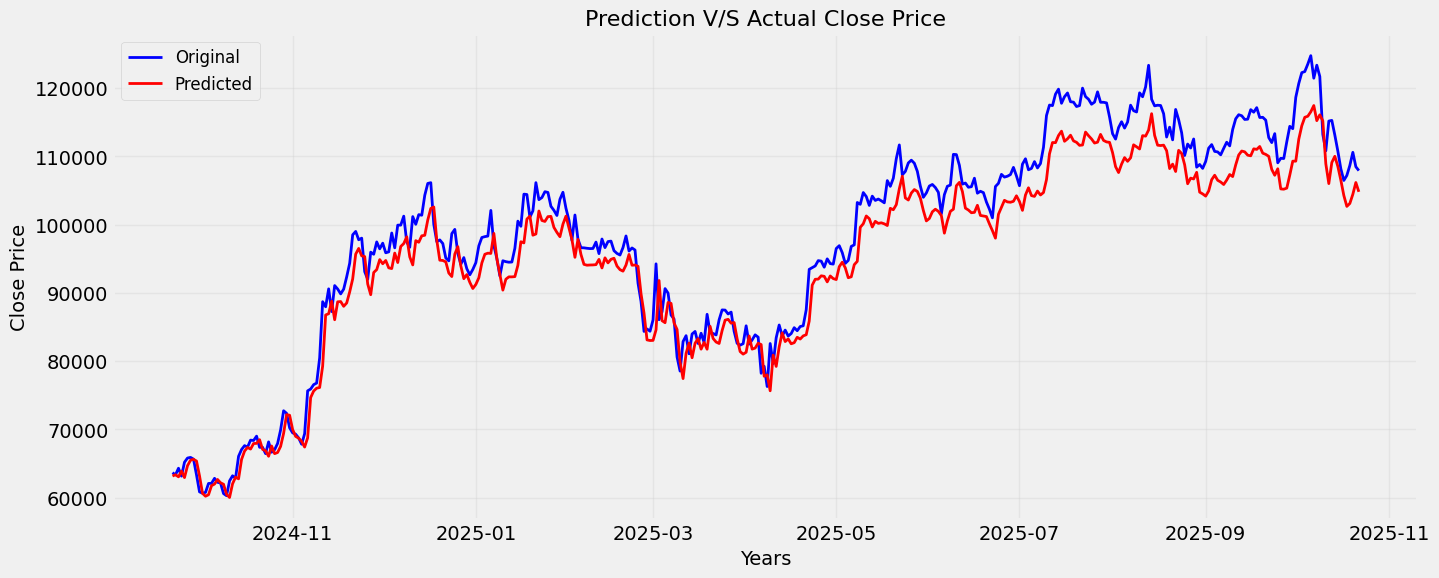

In [96]:
plotting_data = pd.DataFrame({
    'Original': inverse_y_test.flatten(),
    'Predicted': inverse_predictions.flatten(),
}, index=closing_price.index[train_size + base_days:])

plt.figure(figsize=(15,6))
plt.plot(plotting_data.index, plotting_data['Original'], label='Original', color='blue', linewidth=2)
plt.plot(plotting_data.index, plotting_data['Predicted'], label='Predicted', color='red', linewidth=2)

plt.title('Prediction V/S Actual Close Price', fontsize=16)
plt.xlabel('Years', fontsize=14)
plt.ylabel('Close Price', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [97]:
# Predict future days
last_100 = scaled_data[-100:].reshape(1, -1, 1)
future_predictions = []
for _ in range(30):
    next_days = model.predict(last_100)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_100 = np.append(last_100[:, 1:, :], next_days.reshape(1, 1, -1), axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

In [98]:
last_100

array([[[0.94868166],
        [0.94096558],
        [0.94171212],
        [0.94140476],
        [0.93176594],
        [0.90430338],
        [0.91589133],
        [0.90099493],
        [0.93675712],
        [0.92471807],
        [0.90933852],
        [0.88257478],
        [0.89604708],
        [0.89138647],
        [0.90200455],
        [0.86881982],
        [0.87200856],
        [0.86742207],
        [0.87556084],
        [0.89121407],
        [0.89540935],
        [0.88738516],
        [0.88680223],
        [0.88338027],
        [0.89094942],
        [0.89820462],
        [0.89386277],
        [0.91332754],
        [0.9257874 ],
        [0.93055595],
        [0.92934326],
        [0.92498561],
        [0.92528438],
        [0.93650909],
        [0.93350141],
        [0.93886925],
        [0.92724292],
        [0.92750864],
        [0.92417033],
        [0.90363975],
        [0.89774762],
        [0.9082966 ],
        [0.8739449 ],
        [0.87927135],
        [0.87902344],
        [0

In [99]:
future_predictions

[array([[104016.43]], dtype=float32),
 array([[100910.87]], dtype=float32),
 array([[97962.25]], dtype=float32),
 array([[95293.51]], dtype=float32),
 array([[92910.86]], dtype=float32),
 array([[90810.445]], dtype=float32),
 array([[88970.21]], dtype=float32),
 array([[87357.13]], dtype=float32),
 array([[85934.28]], dtype=float32),
 array([[84666.234]], dtype=float32),
 array([[83521.945]], dtype=float32),
 array([[82476.03]], dtype=float32),
 array([[81508.85]], dtype=float32),
 array([[80605.73]], dtype=float32),
 array([[79756.055]], dtype=float32),
 array([[78952.305]], dtype=float32),
 array([[78189.1]], dtype=float32),
 array([[77462.57]], dtype=float32),
 array([[76769.766]], dtype=float32),
 array([[76108.34]], dtype=float32),
 array([[75476.3]], dtype=float32),
 array([[74871.766]], dtype=float32),
 array([[74293.1]], dtype=float32),
 array([[73738.695]], dtype=float32),
 array([[73207.016]], dtype=float32),
 array([[72696.625]], dtype=float32),
 array([[72206.125]], dtype=f

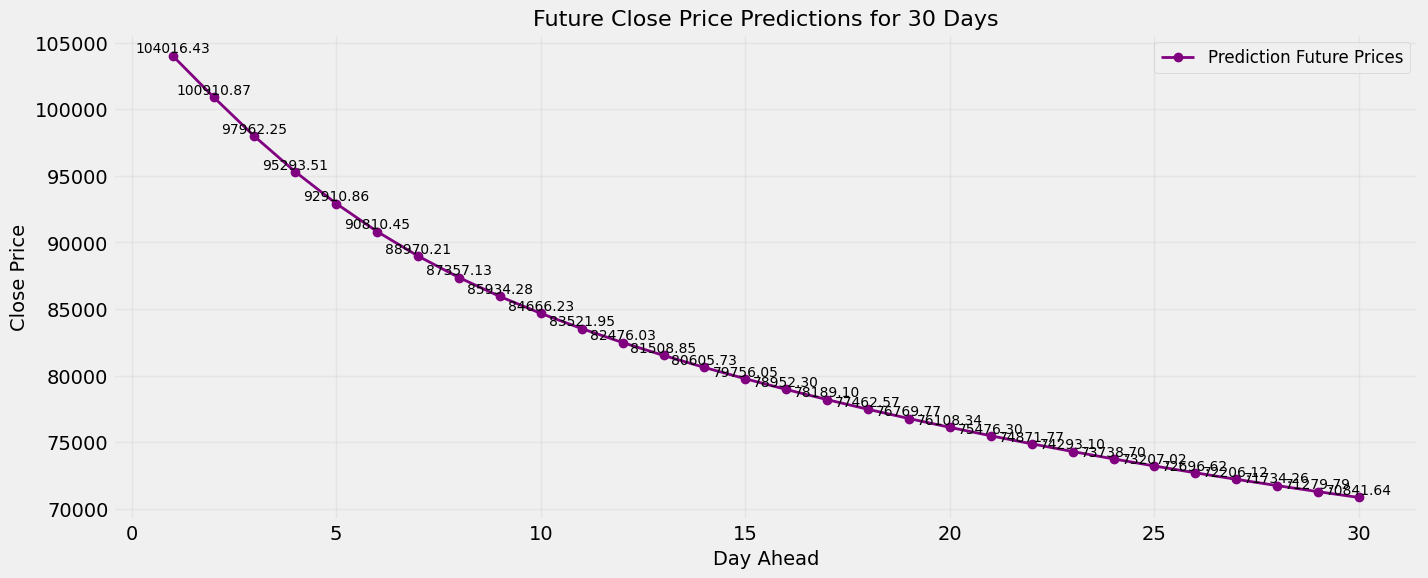

In [100]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize=(15,6))
plt.plot(range(1,31), future_predictions, marker='o', label='Prediction Future Prices', color='purple', linewidth=2)

for i, val in enumerate(future_predictions):
    plt.text(i+1, val, f'{val:.2f}', fontsize=10, ha='center', va='bottom', color='black')

plt.title('Future Close Price Predictions for 30 Days', fontsize=16)
plt.xlabel('Day Ahead', fontsize=14)
plt.ylabel('Close Price', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [102]:
model.save("bitcoin_price_prediction_model.h5")